<a href="https://colab.research.google.com/github/muhammetozcan07/Akilli_sehir_aydinlatma/blob/main/akilli_sehir_aydinlatma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- ADIM 10 ---
Sensörler verisi : Gece, 🌑 Zifiri Karanlık, 💨 Kimsecikler yok
Yapay Zeka Kararı  : Lambayı OFF [Kapalı] yap
Alınan Puan        : 5
-------------------

Test tamamlandı.


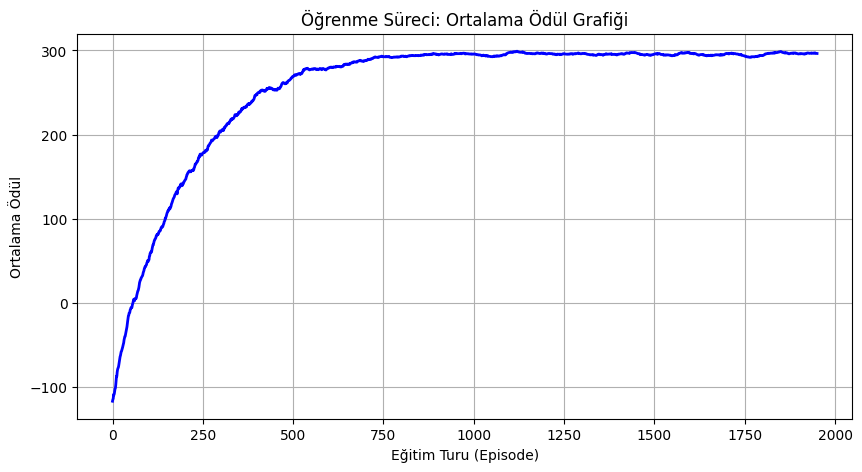

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

class SmartLightingEnv:
    def __init__(self):

        # State (Durum) Uzayları
        self.motions = [0, 1]          # 0: Yok, 1: Var
        self.lights = [0, 1, 2]        # 0: Karanlık, 1: Alacakaranlık, 2: Aydınlık
        self.times = [0, 1, 2, 3]      # 0: Gece, 1: Sabah, 2: Öğle, 3: Akşam

        # Action (Aksiyon) Uzayı
        self.actions = [0, 1, 2]       # 0: Kapalı, 1: %50 Parlaklık, 2: %100 Parlaklık

        self.state = self.reset()

    def reset(self):

        start_time = random.choice(self.times)
        if start_time == 0: start_light = 0         # Gece -> Karanlık
        elif start_time in [1, 3]: start_light = 1  # Sabah/Akşam -> Alacakaranlık
        else: start_light = 2                       # Öğle -> Aydınlık

        self.state = (random.choice(self.motions), start_light, start_time)
        return self.state

    def step(self, action):
        motion, light, time_of_day = self.state

        # ENERJİ CEZASI VE GÜVENLİK PRİMİ HESAPLAMALARI
        if action == 0: energy_penalty = 0
        elif action == 1: energy_penalty = -1
        else: energy_penalty = -2

        safety_bonus = 0
        if motion == 1:
            if light == 0:
                if action == 0: safety_bonus = -10
                elif action == 1: safety_bonus = 2
                elif action == 2: safety_bonus = 5
            elif light == 1:
                if action == 0: safety_bonus = -5
                elif action == 1: safety_bonus = 3
                elif action == 2: safety_bonus = 1
            elif light == 2:
                if action == 0: safety_bonus = 2
                elif action == 1: safety_bonus = -1
                elif action == 2: safety_bonus = -3
        else:
            if action == 0: safety_bonus = 3
            elif action == 1: safety_bonus = -2
            elif action == 2: safety_bonus = -5

        if time_of_day == 0:
            if motion == 1 and action == 2: safety_bonus += 3
            elif motion == 0 and action == 0: safety_bonus += 2

        reward = energy_penalty + safety_bonus

        next_time = (time_of_day + 1) % len(self.times)

        # Gelecek zaman dilimine göre hareket olasılığı tanımlıyoruz
        # 0: Gece (%10), 1: Sabah (%80), 2: Öğle (%40), 3: Akşam (%90)
        motion_probabilities = {0: 0.10, 1: 0.80, 2: 0.40, 3: 0.90}
        prob = motion_probabilities[next_time]

        next_motion = 1 if random.random() < prob else 0

        if next_time == 0: next_light = 0
        elif next_time in [1, 3]: next_light = 1
        else: next_light = 2

        next_state = (next_motion, next_light, next_time)
        self.state = next_state

        return next_state, reward

# --- EĞİTİM ---
env = SmartLightingEnv()

q_table = np.zeros((len(env.motions), len(env.lights), len(env.times), len(env.actions)))

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 2000

rewards_per_episode = []

print("Yapay zeka eğitime başlıyor...")
for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(100):
        if random.uniform(0, 1) < epsilon:
            action = random.choice(env.actions)
        else:
            action = np.argmax(q_table[state[0], state[1], state[2]])

        next_state, reward = env.step(action)

        old_value = q_table[state[0], state[1], state[2], action]
        next_max = np.max(q_table[next_state[0], next_state[1], next_state[2]])

        new_value = old_value + alpha * (reward + gamma * next_max - old_value)
        q_table[state[0], state[1], state[2], action] = new_value

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Eğitim bitti!")

# --- ÖDÜL GRAFİĞİ ---
plt.figure(figsize=(10,5))
window = 50
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')
plt.plot(moving_avg, color='blue', linewidth=2)
plt.title('Öğrenme Süreci: Ortalama Ödül Grafiği')
plt.xlabel('Eğitim Turu (Episode)')
plt.ylabel('Ortalama Ödül')
plt.grid(True)

# --- SİMÜLASYON ---
print("Sistemi canlı test ediyoruz... (10 Adım)")
time.sleep(2)

state = env.reset()
for step in range(10):
    clear_output(wait=True)

    action = np.argmax(q_table[state[0], state[1], state[2]])
    next_state, reward = env.step(action)

    motion_str = "🚶 Biri geçiyor" if state[0] == 1 else "💨 Kimsecikler yok"
    light_str = {0: "🌑 Zifiri Karanlık", 1: "⛅ Hafif Aydınlık", 2: "☀️ Bildiğin Gündüz"}[state[1]]
    time_str = {0: "Gece", 1: "Sabah", 2: "Öğle", 3: "Akşam"}[state[2]]

    action_art = {
        0: "OFF [Kapalı]",
        1: "MID [%50 Güç]",
        2: "MAX [%100 Güç]"
    }[action]

    print(f"--- ADIM {step + 1} ---")
    print(f"Sensörler verisi : {time_str}, {light_str}, {motion_str}")
    print(f"Yapay Zeka Kararı  : Lambayı {action_art} yap")
    print(f"Alınan Puan        : {reward}")
    print("-------------------\n")

    state = next_state
    time.sleep(2)

print("Test tamamlandı.")
plt.show(block=True)